# VRSE lifecycle: learning is not deployment

This no-download notebook visualizes one complete event: the baseline keeps serving while a candidate learns, held-out evidence authorizes a bounded region, unsupported inputs stay on exact fallback, a harmful candidate is rejected, and revoke restores the prior snapshot.

## Setup

From a local clone, install with `python -m pip install -e ".[benchmark]"`. In Colab, clone `https://github.com/Byte-Naut/vrse-pytorch`, change into the repository, and run the same install command.

In [1]:
import matplotlib.pyplot as plt
import torch

from examples.quickstart import FrozenRule, harmful_update, make_model, target

torch.manual_seed(7)
baseline = FrozenRule()
model = make_model(baseline, seed=7)

x_fit = torch.linspace(-1.0, 1.0, 128).unsqueeze(1)
x_calibration = torch.linspace(-0.997, 0.997, 2000).unsqueeze(1)
model.fit(x_fit, target(x_fit), x_calibration)

In [2]:
grid = torch.linspace(-1.5, 6.0, 500).unsqueeze(1)
served_before = model(grid).detach()

stream = torch.linspace(3.0, 4.0, 160).unsqueeze(1)
for chunk in stream.split(20):
    model.observe(chunk, target(chunk))

served_after_observation = model(grid).detach()
unchanged_before_review = torch.equal(served_before, served_after_observation)
unchanged_before_review

True

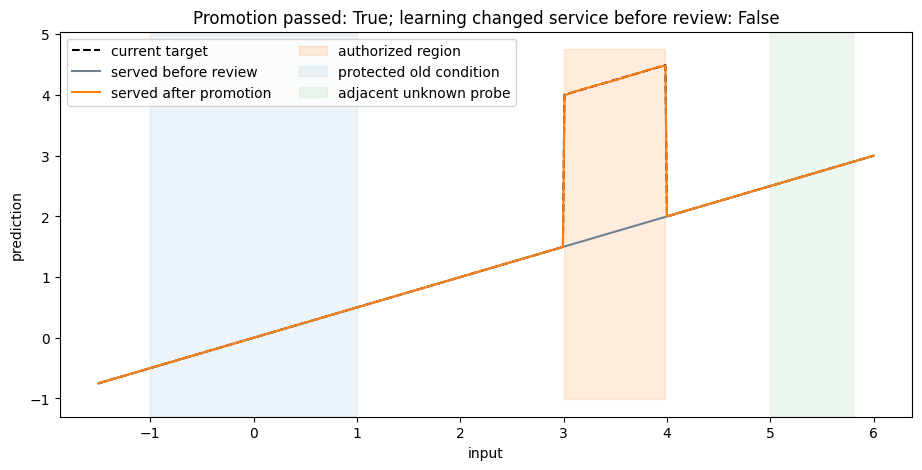

In [3]:
x_validation = torch.linspace(3.01, 3.99, 120).unsqueeze(1)
x_guard = torch.linspace(-0.95, 0.95, 120).unsqueeze(1)
proposal = model.evaluate(x_validation, target(x_validation), guard_x=x_guard)
promoted = model.promote(proposal)
served_after_promotion = model(grid).detach()
route = model.route_mask(grid).detach()

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(grid[:, 0], target(grid)[:, 0], '--', color='black', label='current target')
ax.plot(grid[:, 0], served_before[:, 0], color='slategray', label='served before review')
ax.plot(grid[:, 0], served_after_promotion[:, 0], color='tab:orange', label='served after promotion')
ax.fill_between(grid[:, 0], ax.get_ylim()[0], ax.get_ylim()[1], where=route, alpha=0.14, color='tab:orange', label='authorized region')
ax.axvspan(-1.0, 1.0, alpha=0.08, color='tab:blue', label='protected old condition')
ax.axvspan(5.0, 5.8, alpha=0.08, color='tab:green', label='adjacent unknown probe')
ax.set(xlabel='input', ylabel='prediction', title=f'Promotion passed: {promoted}; learning changed service before review: {not unchanged_before_review}')
ax.legend(ncol=2)
plt.show()

In [4]:
harmful_model = make_model(FrozenRule(), seed=11)
harmful_model.fit(x_fit, target(x_fit), x_calibration)
harmful_model.observe(stream, harmful_update(stream))
harmful_proposal = harmful_model.evaluate(x_validation, target(x_validation), guard_x=x_guard)
harmful_promoted = harmful_model.promote(harmful_proposal)

old_unchanged = torch.equal(model(x_guard), baseline(x_guard))
unknown = torch.linspace(5.0, 5.8, 80).unsqueeze(1)
unknown_unchanged = torch.equal(model(unknown), baseline(unknown))
model.revoke()
rollback_exact = torch.equal(model(grid), baseline(grid))

checks = {
    'candidate learned in isolation': unchanged_before_review,
    'useful candidate promoted': promoted,
    'harmful candidate rejected': not harmful_promoted,
    'old behavior unchanged': old_unchanged,
    'unknown behavior unchanged': unknown_unchanged,
    'revoke restored baseline': rollback_exact,
}
checks

{'candidate learned in isolation': True,
 'useful candidate promoted': True,
 'harmful candidate rejected': True,
 'old behavior unchanged': True,
 'unknown behavior unchanged': True,
 'revoke restored baseline': True}

## Interpretation

The shaded region is permission, not a statement that every point inside it is safe. Exact fallback is a software invariant outside the region; the quality and statistical meaning of the region itself remain research questions.